# Tugas Transformasi Geometri

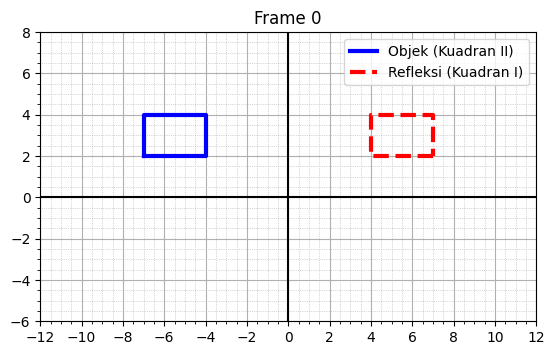

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# =========================
# OBJEK (SEKARANG DI KUADRAN II)
# =========================
objek = np.array([
  [-7, 2],
  [-4, 2],
  [-4, 4],
  [-7, 4],
  [-7, 2]
])

# =========================
# TRANSFORMASI
# =========================

# refleksi sumbu-Y
R = np.array([
  [-1, 0],
  [0, 1]
])

# translasi homogen
def T(tx, ty):
  return np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
  ])

def ke_homogen(obj):
  return np.hstack((obj, np.ones((obj.shape[0],1))))

def ke_cartesian(obj):
  return obj[:, :2]

# =========================
# PLOT
# =========================
fig, ax = plt.subplots()

def update(frame):
  ax.clear()

  ax.set_xlim(-12, 12)
  ax.set_ylim(-6, 8)
  ax.set_aspect('equal')

  # sumbu
  ax.axhline(0, color='black')
  ax.axvline(0, color='black')

  # grid
  ax.set_xticks(np.arange(-12, 13, 2))
  ax.set_yticks(np.arange(-6, 9, 2))
  ax.grid(True)

  ax.set_xticks(np.arange(-12, 12, 0.5), minor=True)
  ax.set_yticks(np.arange(-6, 8, 0.5), minor=True)
  ax.grid(which='minor', linestyle=':', linewidth=0.5)

  # =========================
  # GERAK
  # =========================
  t = frame * 0.5

  obj_h = ke_homogen(objek)

  # objek utama (kiri → ke kanan)
  kiri = (T(t, 0) @ obj_h.T).T
  kiri = ke_cartesian(kiri)

  # refleksi awal (jadi di kanan / kuadran I)
  kanan_awal = (R @ objek.T).T
  kanan_h = ke_homogen(kanan_awal)

  # refleksi bergerak ke kiri
  kanan = (T(-t, 0) @ kanan_h.T).T
  kanan = ke_cartesian(kanan)

  # gambar
  ax.plot(kiri[:,0], kiri[:,1], 'b-', linewidth=3, label='Objek (Kuadran II)')
  ax.plot(kanan[:,0], kanan[:,1], 'r--', linewidth=3, label='Refleksi (Kuadran I)')

  ax.legend()
  ax.set_title(f"Frame {frame}")

# animasi
anim = FuncAnimation(fig, update, frames=25, interval=200)

HTML(anim.to_jshtml())